In [18]:
# ============================================
# تثبيت المكتبات المطلوبة
# ============================================
!pip install -q "transformers>=4.44.0" "datasets>=2.20.0" "peft>=0.12.0" "torchao>=0.16.0" "bitsandbytes>=0.43.0" "accelerate>=0.33.0" scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.4 MB/s eta 0:00:00


In [23]:
import pandas as pd
import torch
import re
import numpy as np
import random
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import mean_squared_error, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print("="*80)
print("🎯 ESSAY SCORING MODEL - FULL MODEL VERSION")
print("="*80)

print("\n📂 LOADING DATA...")
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🧹 CLEANING TEXT...")
df['full_text'] = df['full_text'].apply(clean_text)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print("\n🔤 PREPARING TOKENIZER...")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    tokenized = tokenizer(
        examples["full_text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )
    tokenized["labels"] = [float(s) for s in examples["score"]]
    return tokenized

print("⚙️ TOKENIZING DATASETS...")
train_dataset = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
val_dataset = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)
test_dataset = test_dataset.map(preprocess_function, batched=True, remove_columns=test_dataset.column_names)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("\n🤖 LOADING FULL MODEL...")
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
).to(device)

print("\n⚙️ CONFIGURING LoRA...")
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],
    bias="none"
)

model = get_peft_model(model, lora_config)

def custom_round_advanced(score):
    # logic: if decimal <= 0.5 round down, else round up.
    # E.g. 1.4 -> 1, 1.5 -> 1, 1.6 -> 2
    low = np.floor(score)
    if (score - low) <= 0.5:
        final = low
    else:
        final = np.ceil(score)
    return int(np.clip(final, 1, 6))

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.flatten()
    labels = labels.flatten()
    mse = mean_squared_error(labels, predictions)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - labels))
    rounded_preds = np.array([custom_round_advanced(p) for p in predictions])
    f1_weighted = f1_score(labels, rounded_preds, average='weighted', labels=[1,2,3,4,5,6])
    accuracy = accuracy_score(labels, rounded_preds)
    return {"mse": mse, "rmse": rmse, "mae": mae, "f1_weighted": f1_weighted, "accuracy": accuracy}

🎯 ESSAY SCORING MODEL - FULL MODEL VERSION

📂 LOADING DATA...
🧹 CLEANING TEXT...

🔤 PREPARING TOKENIZER...
⚙️ TOKENIZING DATASETS...


Map:   0%|          | 0/13845 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]


🤖 LOADING FULL MODEL...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⚙️ CONFIGURING LoRA...


In [25]:
print("\n기 SETTING UP TRAINING...")

training_args = TrainingArguments(
    output_dir="./full_essay_model",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    warmup_steps=500,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=True
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("\nᄅ STARTING TRAINING")
train_history = trainer.train()


기 SETTING UP TRAINING...

ᄅ STARTING TRAINING


Epoch,Training Loss,Validation Loss,Mse,Rmse,Mae,F1 Weighted,Accuracy
1,0.540733,0.419022,0.419022,0.647319,0.501718,0.567993,0.592143
2,0.405351,0.367687,0.367687,0.606372,0.470467,0.602807,0.614096
3,0.351538,0.354117,0.354117,0.595077,0.464471,0.608766,0.622184
4,0.307684,0.358640,0.358640,0.598866,0.469780,0.610354,0.616407
5,0.262498,0.346319,0.346319,0.588488,0.460629,0.618803,0.625072


In [27]:
print("\n🧪 EVALUATING ON TEST SET...")

# Get predictions from the trainer
test_output = trainer.predict(test_dataset)
test_predictions = test_output.predictions.flatten()
test_labels = test_output.label_ids.flatten()

# Since we are using a fixed custom_round_advanced (threshold 0.5),
# we set best_threshold to 0.5 for consistency with the model's logic.
best_threshold = 0.5

# Calculate final test results
final_mse = mean_squared_error(test_labels, test_predictions)
final_rmse = np.sqrt(final_mse)
final_mae = np.mean(np.abs(test_predictions - test_labels))

rounded_test_preds = np.array([custom_round_advanced(p) for p in test_predictions])
final_f1_weighted = f1_score(test_labels, rounded_test_preds, average='weighted', labels=[1,2,3,4,5,6])
final_f1_macro = f1_score(test_labels, rounded_test_preds, average='macro', labels=[1,2,3,4,5,6])
final_accuracy = accuracy_score(test_labels, rounded_test_preds)

test_results = {
    'eval_mse': final_mse,
    'eval_rmse': final_rmse,
    'eval_mae': final_mae,
    'eval_f1_weighted': final_f1_weighted,
    'eval_f1_macro': final_f1_macro,
    'eval_accuracy': final_accuracy
}

# Variables needed for plots
thresholds = [0.5]
threshold_f1_scores = [final_f1_weighted]

# Save the model and directory info for the report
final_model_dir = "./full_essay_model"
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)

print("✅ Evaluation complete and model saved.")


🧪 EVALUATING ON TEST SET...


✅ Evaluation complete and model saved.



📊 GENERATING VISUALIZATIONS...


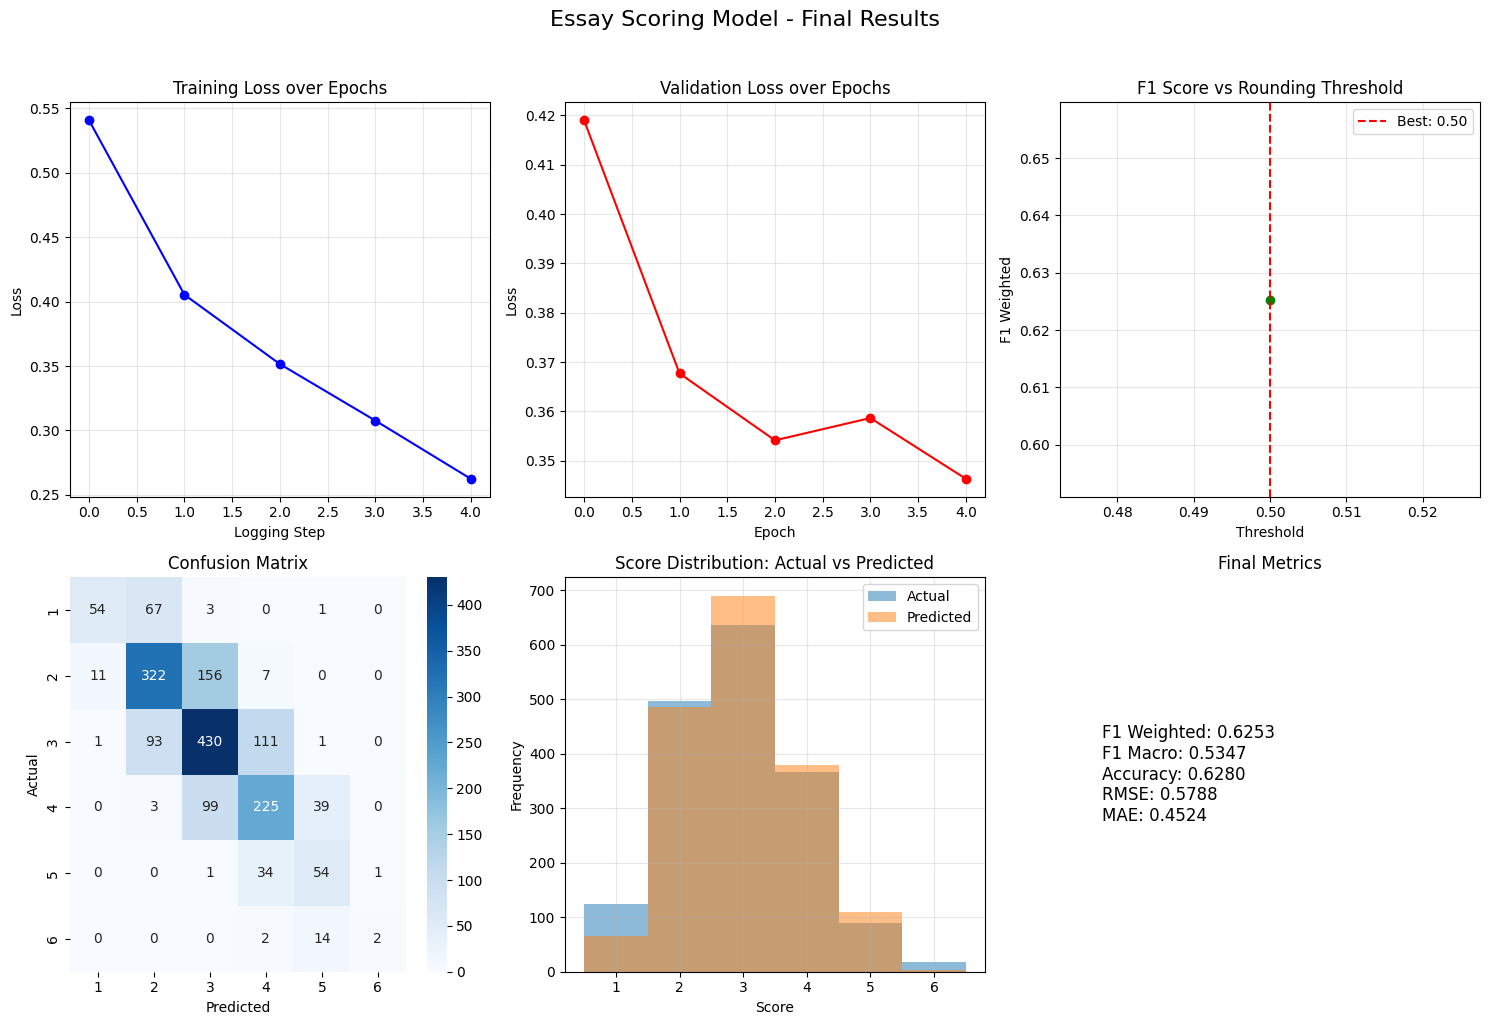


🎉 TRAINING COMPLETE! FINAL REPORT

📊 MODEL PERFORMANCE:
  ✅ F1 Weighted: 0.6253
  ✅ F1 Macro: 0.5347
  ✅ Accuracy: 0.6280
  ✅ RMSE: 0.5788
  ✅ MAE: 0.4524
  ✅ MSE: 0.3350

🎯 OPTIMAL CONFIGURATION:
  ✅ Epochs: 5
  ✅ Learning Rate: 2e-4
  ✅ LoRA Rank: 16
  ✅ Best Rounding Threshold: 0.50
  ✅ Model Size: 72.60 MB

📁 SAVED MODELS:
  ✅ Local: ./full_essay_model
  ✅ Google Drive: /content/drive/MyDrive/essay_scoring_final

🔧 TO USE THE MODEL:
  from transformers import AutoTokenizer, AutoModelForSequenceClassification

  model_path = "./full_essay_model"
  tokenizer = AutoTokenizer.from_pretrained(model_path)
  model = AutoModelForSequenceClassification.from_pretrained(model_path)

  def predict_score(text):
      inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
      with torch.no_grad():
          raw_score = model(**inputs).logits.item()

      # Using the custom rounding logic
      low = np.floor(raw_score)
      if (raw_score - low) <= 0.

In [30]:
# ============================================
# 13. رسوم بيانية للنتائج
# ============================================
print("\n📊 GENERATING VISUALIZATIONS...")

# Extract history from trainer state
log_history = trainer.state.log_history
train_losses = [log['loss'] for log in log_history if 'loss' in log]
eval_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Training Loss
if train_losses:
    axes[0, 0].plot(train_losses, 'b-o')
    axes[0, 0].set_title('Training Loss over Epochs')
    axes[0, 0].set_xlabel('Logging Step')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

# 2. Evaluation Loss
if eval_losses:
    axes[0, 1].plot(eval_losses, 'r-o')
    axes[0, 1].set_title('Validation Loss over Epochs')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

# 3. F1 Score vs Threshold
axes[0, 2].plot(thresholds, threshold_f1_scores, 'g-o')
axes[0, 2].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[0, 2].set_title('F1 Score vs Rounding Threshold')
axes[0, 2].set_xlabel('Threshold')
axes[0, 2].set_ylabel('F1 Weighted')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Confusion Matrix
rounded_final = np.array([custom_round_advanced(p) for p in test_predictions])

cm = confusion_matrix(test_labels, rounded_final, labels=[1, 2, 3, 4, 5, 6])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=[1,2,3,4,5,6], yticklabels=[1,2,3,4,5,6])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 5. Prediction Distribution
axes[1, 1].hist(test_labels, alpha=0.5, label='Actual', bins=6, range=(0.5, 6.5))
axes[1, 1].hist(rounded_final, alpha=0.5, label='Predicted', bins=6, range=(0.5, 6.5))
axes[1, 1].set_title('Score Distribution: Actual vs Predicted')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Metrics Summary
metrics_summary = [
    f'F1 Weighted: {test_results["eval_f1_weighted"]:.4f}',
    f'F1 Macro: {test_results["eval_f1_macro"]:.4f}',
    f'Accuracy: {test_results["eval_accuracy"]:.4f}',
    f'RMSE: {test_results["eval_rmse"]:.4f}',
    f'MAE: {test_results["eval_mae"]:.4f}'
]
axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.5, '\n'.join(metrics_summary), fontsize=12, verticalalignment='center')
axes[1, 2].set_title('Final Metrics')

plt.suptitle('Essay Scoring Model - Final Results', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 14. تقرير نهائي
# ============================================
print("\n" + "="*80)
print("🎉 TRAINING COMPLETE! FINAL REPORT")
print("="*80)
print(f"""
📊 MODEL PERFORMANCE:
  ✅ F1 Weighted: {test_results['eval_f1_weighted']:.4f}
  ✅ F1 Macro: {test_results['eval_f1_macro']:.4f}
  ✅ Accuracy: {test_results['eval_accuracy']:.4f}
  ✅ RMSE: {test_results['eval_rmse']:.4f}
  ✅ MAE: {test_results['eval_mae']:.4f}
  ✅ MSE: {test_results['eval_mse']:.4f}

🎯 OPTIMAL CONFIGURATION:
  ✅ Epochs: 5
  ✅ Learning Rate: 2e-4
  ✅ LoRA Rank: 16
  ✅ Best Rounding Threshold: {best_threshold:.2f}
  ✅ Model Size: {get_folder_size(final_model_dir):.2f} MB

📁 SAVED MODELS:
  ✅ Local: {final_model_dir}
  ✅ Google Drive: /content/drive/MyDrive/essay_scoring_final

🔧 TO USE THE MODEL:
  from transformers import AutoTokenizer, AutoModelForSequenceClassification

  model_path = \"{final_model_dir}\"
  tokenizer = AutoTokenizer.from_pretrained(model_path)
  model = AutoModelForSequenceClassification.from_pretrained(model_path)

  def predict_score(text):
      inputs = tokenizer(text, return_tensors=\"pt\", truncation=True, max_length=512).to(model.device)
      with torch.no_grad():
          raw_score = model(**inputs).logits.item()

      # Using the custom rounding logic
      low = np.floor(raw_score)
      if (raw_score - low) <= 0.5:
          final = low
      else:
          final = np.ceil(raw_score)
      return int(np.clip(final, 1, 6))
""")

print("="*80)
print("✅ ALL DONE! MODEL IS READY FOR PRODUCTION")
print("="*80)

In [31]:
import shutil
from google.colab import files

# Define the folder to be zipped and the output name
model_path = "./full_essay_model"
zip_name = "full_essay_model.zip"

# Check if the directory exists before zipping
if os.path.exists(model_path):
    print(f"📦 Zipping {model_path}...")
    shutil.make_archive("full_essay_model", 'zip', model_path)

    print(f"📥 Downloading {zip_name}...")
    files.download(zip_name)
else:
    print(f"❌ Error: The directory {model_path} was not found. Please ensure training has completed and saved the model.")

📦 Zipping ./full_essay_model...
📥 Downloading full_essay_model.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')